# Задача: Отобразить высокомерные данные $X ∈ ℝ^D$ в низкомерное пространство $Y ∈ ℝ^d (d=2,3)$ так, чтобы сохранить структуру соседства.

    1. Вероятностная постановка задачи


Задача: Отобразить высокомерные данные $X ∈ ℝ^D$ в низкомерное пространство $Y ∈ ℝ^d (d=2,3)$
так, чтобы сохранить структуру соседства.


        - Вероятности в исходном пространстве

Гауссово ядро для измерения сходства:

$
p_{j|i} = exp(-||x_i - x_j||^2 / (2σ_i^2)) / Σ_{k≠i} exp(-||x_i - x_k||^2 / (2σ_i^2))$

Симметризация вероятностей:

$
p_{ij} = (p_{j|i} + p_{i|j}) / (2n)$

Перплексия (perplexity) как гиперпараметр:

$
Perp(P_i) = 2^{H(P_i)}, $

где $H(P_i) = -Σ_j p_{j|i} log₂ p_{j|i}$

        - Вероятности в целевом пространстве

Распределение Стьюдента с одной степенью свободы:

$
q_{ij} = (1 + ||y_i - y_j||^2)^{-1} / Σ_{k≠l} (1 + ||y_k - y_l||^2)^{-1}$

Преимущества t-распределения:

       * Тяжелые хвосты

       * Устойчивость к проклятию размерности

       * Улучшенное разделение кластеров

       * Функция стоимости (KL-дивергенция)

$C(Y) = KL(P||Q) = Σ_i Σ_j p_{ij} log(p_{ij} / q_{ij})$

    2. Оптимизация функции стоимости

        2.1. Градиент функции стоимости

$∂C/∂y_i = 4 Σ_j (p_{ij} - q_{ij})(y_i - y_j)(1 + ||y_i - y_j||^2)^{-1}$

       2.2. Методы оптимизации

Градиентный спуск с моментумом:

$Y^{(t)} = Y^{(t-1)} + η ∂C/∂Y + α(t)(Y^{(t-1)} - Y^{(t-2)})$


Раннее преувеличение (early exaggeration):


$p_{ij} ← p_{ij} × 4 (первые 100 итераций)$


Адаптивное обучение (adaptive learning rate)

        2.3. Сложности оптимизации

            - Невыпуклость функции стоимости

            - Локальные минимумы

            - Чувствительность к начальной инициализации

            - Вычислительная сложность O(n²)

Импорт библиотек

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler, LabelEncoder


# Задание

1. Провести исследование влияния гиперпараметров на результаты кластеризации с T-SNE
2. Сравнить с PCA
   
Использовать 2 датасета - стандартного типа Ирис или Цифры, и своего. Не забываем про нормировку и eda в целом

In [4]:
# путь к вашему файлу
path = "my_data.csv"  # замените на реальный путь

df = pd.read_csv(path)
df.head()


,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
0,25.4,round,3089.2,137.1,green,sweet,watermelon
1,24.6,round,3283.9,163.8,green,sweet,watermelon
2,7.8,round,319.0,91.3,green,sweet,custard apple
3,20.0,oval,1607.0,85.7,orange,sweet,papaya
4,10.2,long,131.5,37.8,yellow,sweet,banana


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   size (cm)      10000 non-null  float64
 1   shape          10000 non-null  object 
 2   weight (g)     10000 non-null  float64
 3   avg_price (₹)  10000 non-null  float64
 4   color          10000 non-null  object 
 5   taste          10000 non-null  object 
 6   fruit_name     10000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB


In [7]:
df['fruit_name'].value_counts()

,count
fruit_name,
pear,534
pomegranate,534
pineapple,533
custard apple,516
papaya,509
kiwi,506
blueberry,503
banana,502
coconut,502


Преобразования датасета взяты из лр1

In [22]:
def _keep_top_classes(df: pd.DataFrame, target_col: str, n_classes: int) -> pd.DataFrame:
        """Топ n самых частых классов в датасете"""
        uniq = df[target_col].nunique()
        if n_classes >= uniq:
            return df

        top = df[target_col].value_counts().head(n_classes).index
        trimmed = df[df[target_col].isin(top)]
        return trimmed

def _make_preprocessor(numeric_cols: list[str], cat_cols: list[str]) -> ColumnTransformer:
      """Преобразование числовых и категориальных признаков."""
      return ColumnTransformer(
          transformers=[
              ("num", StandardScaler(), numeric_cols),
              ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_cols),
          ]
      )

In [23]:
n_classes = 4
df = _keep_top_classes(df, target_col="fruit_name", n_classes=int(n_classes))

X_raw = df.drop(columns=["fruit_name"])
y_raw = df["fruit_name"]

# Кодируем целевую переменную и сохраняем названия классов
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)
class_names = label_encoder.classes_

print(f"Классы: {class_names}")

# Преобразуем X
numerical_features = ["size (cm)", "weight (g)", "avg_price (₹)"]
categorical_features = ["shape", "color", "taste"]

preprocessor = _make_preprocessor(numerical_features, categorical_features)
X_transformed = preprocessor.fit_transform(X_raw)

cat_encoder = preprocessor.named_transformers_["cat"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
feature_names = numerical_features + list(cat_feature_names)

Классы: ['custard apple' 'pear' 'pineapple' 'pomegranate']


In [32]:
from sklearn.datasets import load_digits

# 1. Загрузка данных
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

scaler = StandardScaler()
X_digits_scaled = scaler.fit_transform(X_digits)
print(X_digits_scaled.shape, y_digits.shape)

(1797, 64) (1797,)


Разделить выборку на фичи и целевую переменную

In [25]:
feature_cols = 'fruit_name'
X = X_transformed
y = y_encoded

print(X.shape, y.shape)


(2117, 7) (2117,)


pca = PCA(n_components=2, random_state=42)

Датасет фруктов

Доля объяснённой дисперсии: [0.60952921 0.34733143] Суммарно: 0.9568606373688564


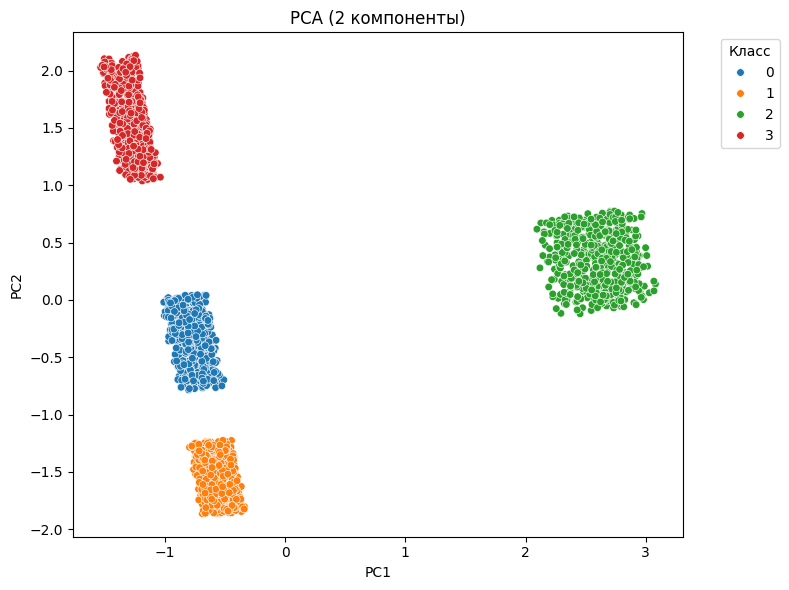

In [48]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

print("Доля объяснённой дисперсии:", pca.explained_variance_ratio_ ,
      "Суммарно:",  pca.explained_variance_ratio_.sum() )

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="tab10", s=30)
plt.title("PCA (2 компоненты)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Класс", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Датаест digits

Доля объяснённой дисперсии: [0.12033916 0.09561054] Суммарно: 0.21594970500832789


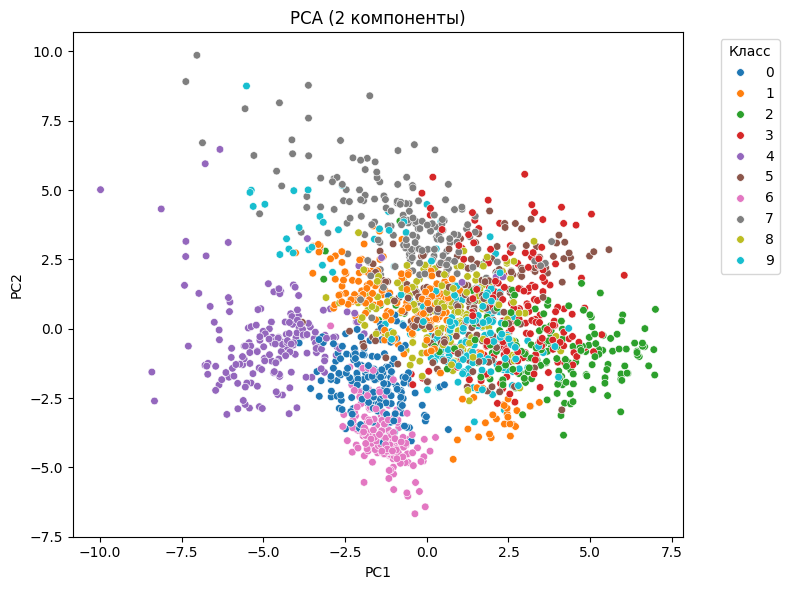

In [39]:
pca = PCA(n_components=2, random_state=42)
X_pca_digits = pca.fit_transform(X_digits_scaled)

print("Доля объяснённой дисперсии:", pca.explained_variance_ratio_ ,
      "Суммарно:",  pca.explained_variance_ratio_.sum() )

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca_digits[:, 0], y=X_pca_digits[:, 1], hue=y_digits, palette="tab10", s=30)
plt.title("PCA (2 компоненты)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Класс", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


TSNE 2 компоненты

Датасет фруктов

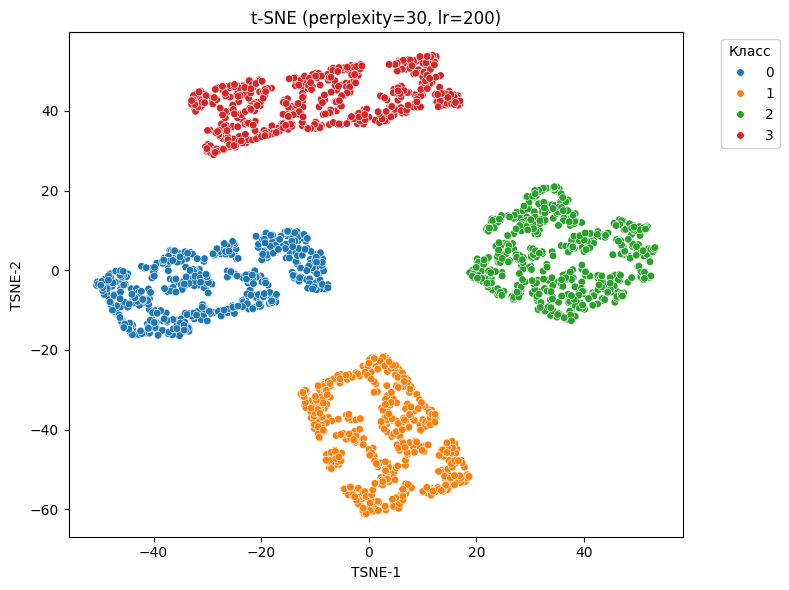

In [51]:
tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette="tab10", s=30)
plt.title("t-SNE (perplexity=30, lr=200)")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.legend(title="Класс", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Датаест digits

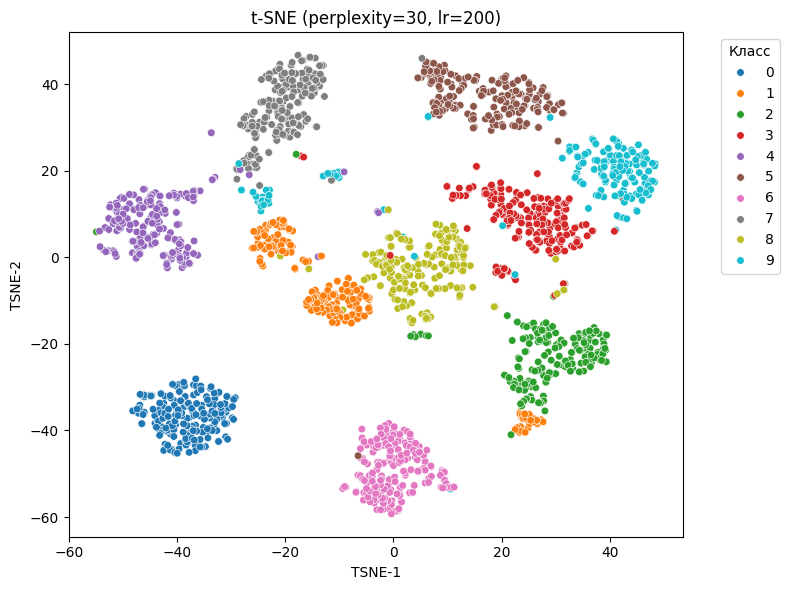

In [44]:
tsne = TSNE(
    n_components=2,
    random_state=42,
    learning_rate=200
)

X_tsne_digits = tsne.fit_transform(X_digits_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_tsne_digits[:, 0], y=X_tsne_digits[:, 1], hue=y_digits, palette="tab10", s=30)
plt.title("t-SNE (perplexity=30, lr=200)")
plt.xlabel("TSNE-1")
plt.ylabel("TSNE-2")
plt.legend(title="Класс", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


Датасет фруктов

In [53]:
from sklearn.metrics import pairwise_distances

def separation_score(X_2d, y):
    D = pairwise_distances(X_2d)
    same = D[y[:, None] == y[None, :]]
    diff = D[y[:, None] != y[None, :]]
    return same.mean(), diff.mean(), diff.mean() / same.mean()

pca_same, pca_diff, pca_ratio = separation_score(X_pca, y)
tsne_same, tsne_diff, tsne_ratio = separation_score(X_tsne, y)

print("PCA:  среднее расстояние внутри класса =", pca_same,
      ", между классами =", pca_diff,
      ", ratio =", pca_ratio)
print("t-SNE: среднее расстояние внутри класса =", tsne_same,
      ", между классами =", tsne_diff,
      ", ratio =", tsne_ratio)


PCA:  среднее расстояние внутри класса = 0.3390703817160617 , между классами = 2.9572078097052885 , ratio = 8.721516148767193
t-SNE: среднее расстояние внутри класса = 17.394361 , между классами = 62.808258 , ratio = 3.61084


Датаест digits

In [54]:
pca_same_digits, pca_diff_digits, pca_ratio_digits = separation_score(X_pca_digits, y_digits)
tsne_same_digits, tsne_diff_digits, tsne_ratio_digits = separation_score(X_tsne_digits, y_digits)

print("PCA:  среднее расстояние внутри класса =", pca_same_digits,
      ", между классами =", pca_diff_digits,
      ", ratio =", pca_ratio_digits)
print("t-SNE: среднее расстояние внутри класса =", tsne_same_digits,
      ", между классами =", tsne_diff_digits,
      ", ratio =", tsne_ratio_digits)


PCA:  среднее расстояние внутри класса = 2.4682343991638254 , между классами = 4.761456156687813 , ratio = 1.9290939945982732
t-SNE: среднее расстояние внутри класса = 13.243143 , между классами = 54.21295 , ratio = 4.093662


Вычислить и отрисовать T-SNE с разным значением Perplexity

Датасет фруктов

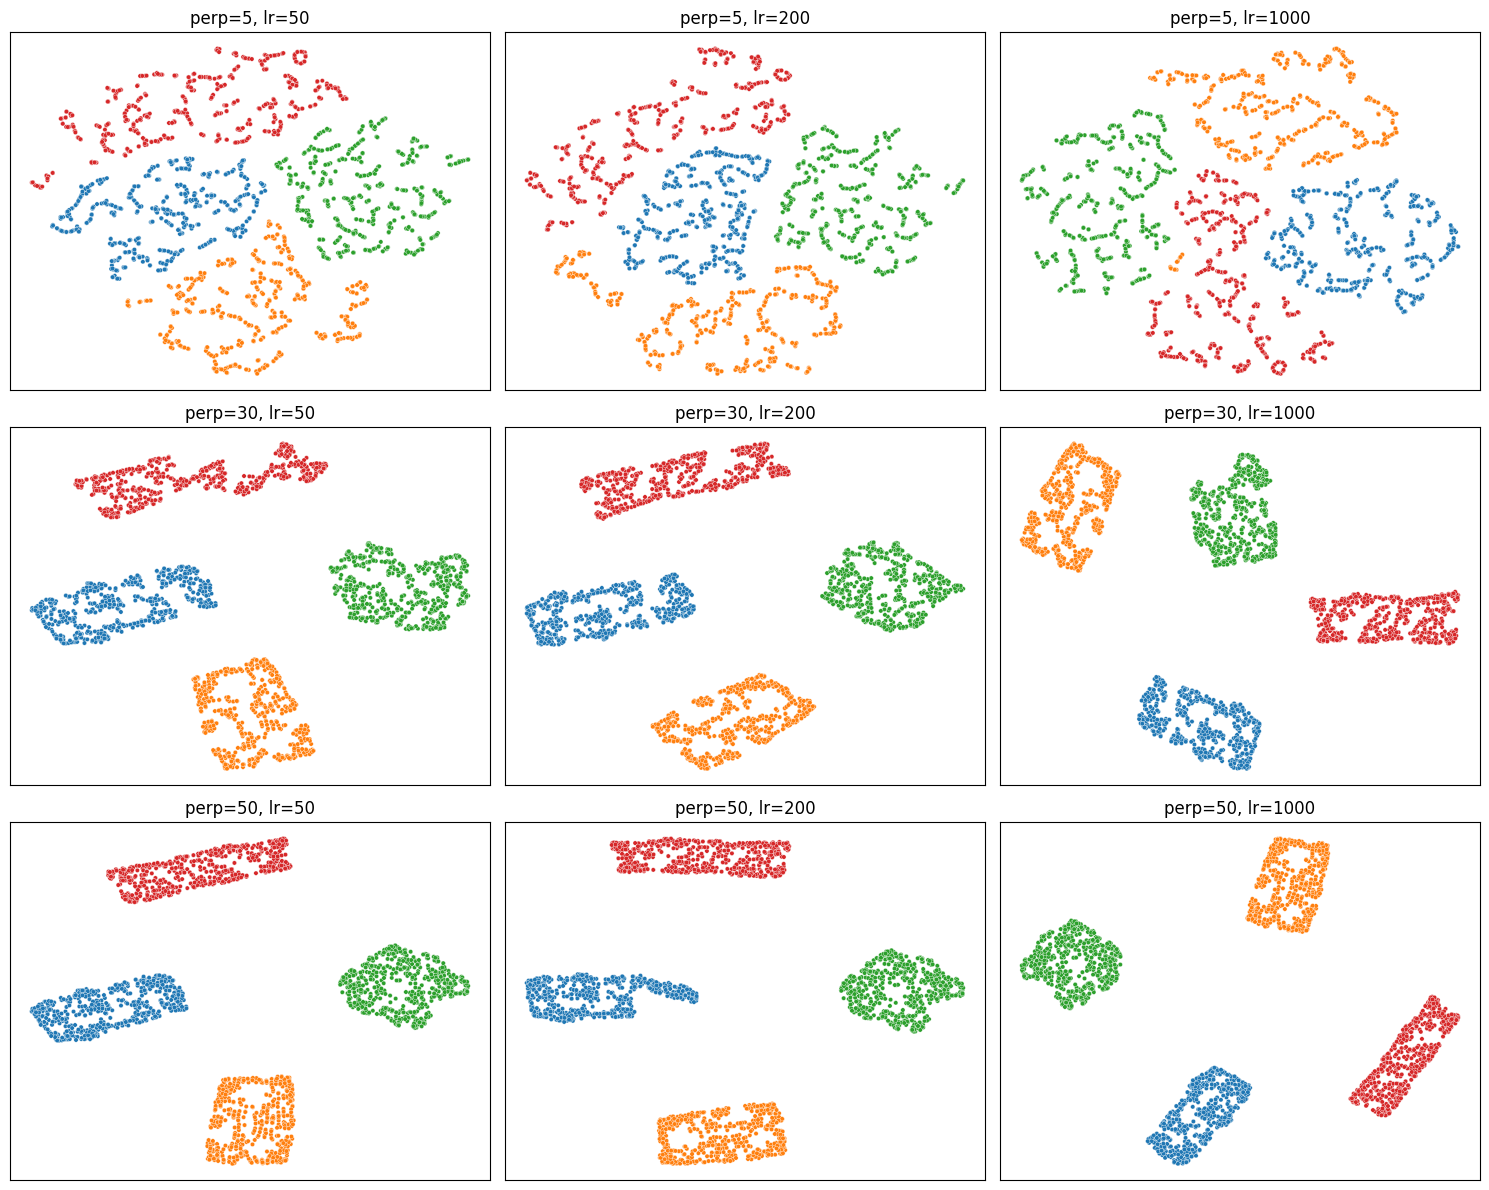

In [55]:
perplexities = [5, 30, 50]
learning_rates = [50, 200, 1000]

fig, axes = plt.subplots(len(perplexities), len(learning_rates),
                         figsize=(5*len(learning_rates), 4*len(perplexities)))

for i, perp in enumerate(perplexities):
    for j, lr in enumerate(learning_rates):
        tsne = TSNE(
            perplexity=perp,
            learning_rate=lr,
            random_state=42
        )
        X_emb = tsne.fit_transform(X)
        ax = axes[i, j]
        sns.scatterplot(x=X_emb[:, 0], y=X_emb[:, 1],
                        hue=y, palette="tab10", s=10, ax=ax, legend=False)
        ax.set_title(f"perp={perp}, lr={lr}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


При больших значения perplexity явно различыми отдельные кластеры

небольшие изменения perplexity кластеры ращличимы, но более "разряжены" чем при больших

небольшие изменения learn rate практически не влияет на результат

Датаест digits

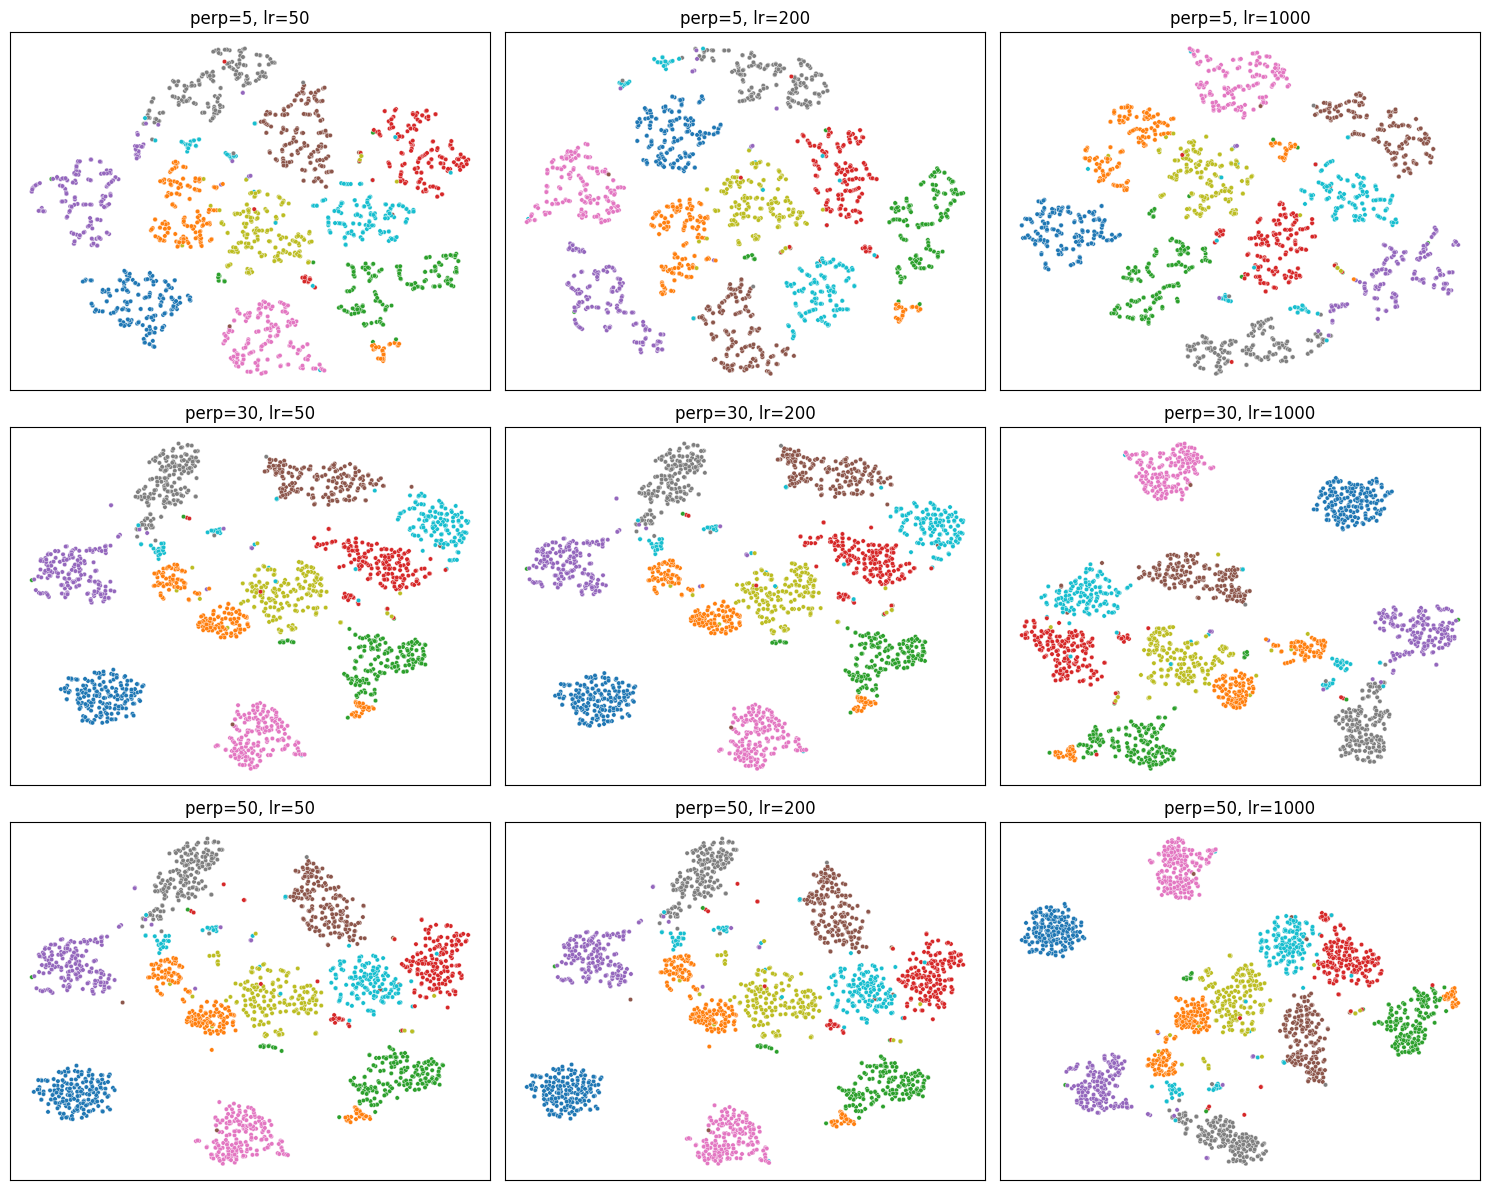

In [58]:
perplexities = [5, 30, 50]
learning_rates = [50, 200, 1000]

fig, axes = plt.subplots(len(perplexities), len(learning_rates),
                         figsize=(5*len(learning_rates), 4*len(perplexities)))

for i, perp in enumerate(perplexities):
    for j, lr in enumerate(learning_rates):
        tsne = TSNE(
            perplexity=perp,
            learning_rate=lr,
            random_state=42
        )
        X_emb = tsne.fit_transform(X_digits_scaled)
        ax = axes[i, j]
        sns.scatterplot(x=X_emb[:, 0], y=X_emb[:, 1],
                        hue=y_digits, palette="tab10", s=10, ax=ax, legend=False)
        ax.set_title(f"perp={perp}, lr={lr}")
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()


При маленьких значениях perplexity кластеры "разряжены"

learning_rate влияет на результат только при больших значениях

При увеличении обоих параметров увеличивается расстояния между кластерами

Проанализируйте:

как меняется форма кластеров,

возникают ли “разрывы” или слияния при разных параметрах,

насколько стабилен рисунок при небольших изменениях параметров.

PCA: устойчивая структура
Для PCA параметров немного (по сути только число компонент), проекция при фиксированном random_state практически не меняется, что показывает устойчивость метода.

Можно показать, что при разных n_components (2, 3, больше) первые две компоненты остаются близкими, а общая структура мало меняется.

In [79]:
n_components = [i for i in range(2,6)]

Датасет фруктов

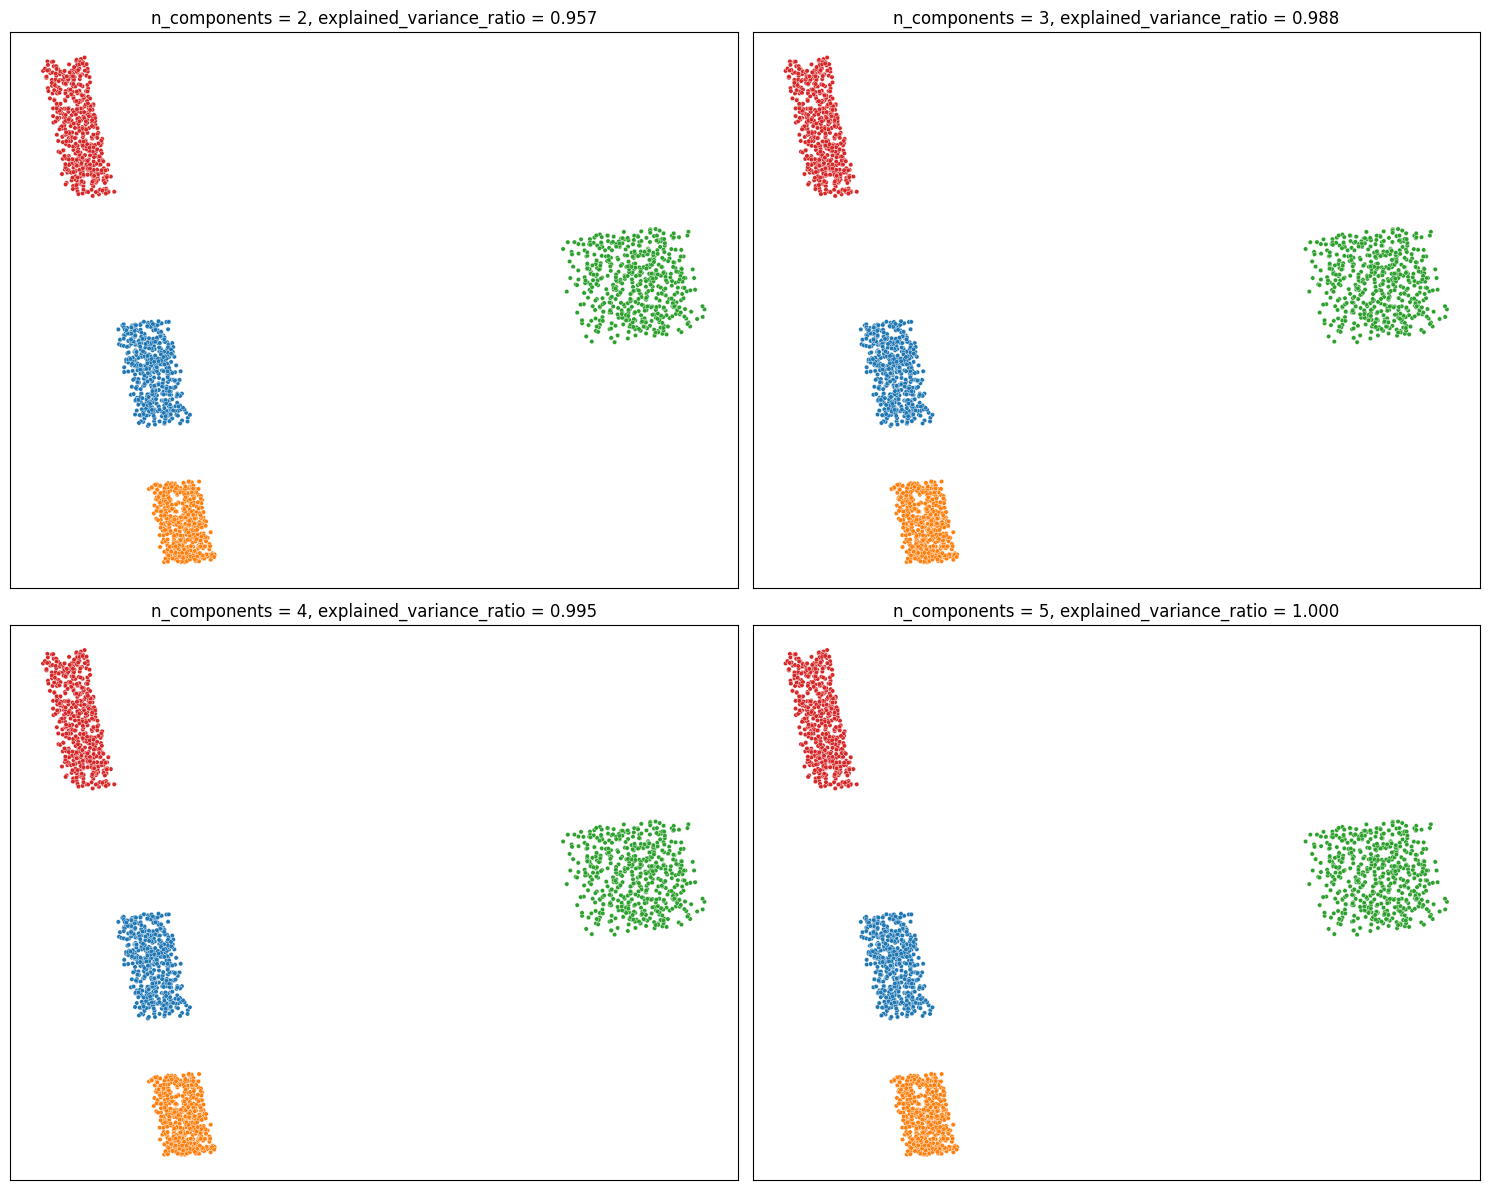

In [83]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for i, n_comp in enumerate(n_components):
    pca = PCA(n_components=n_comp, random_state=42)
    X_pca = pca.fit_transform(X)
    ax = axes[i // 2, i % 2]
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                    hue=y, palette="tab10", s=10, ax=ax, legend=False)
    ax.set_title(f"n_components = {n_comp}, explained_variance_ratio = {pca.explained_variance_ratio_.sum():.3f}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

Датасет digits

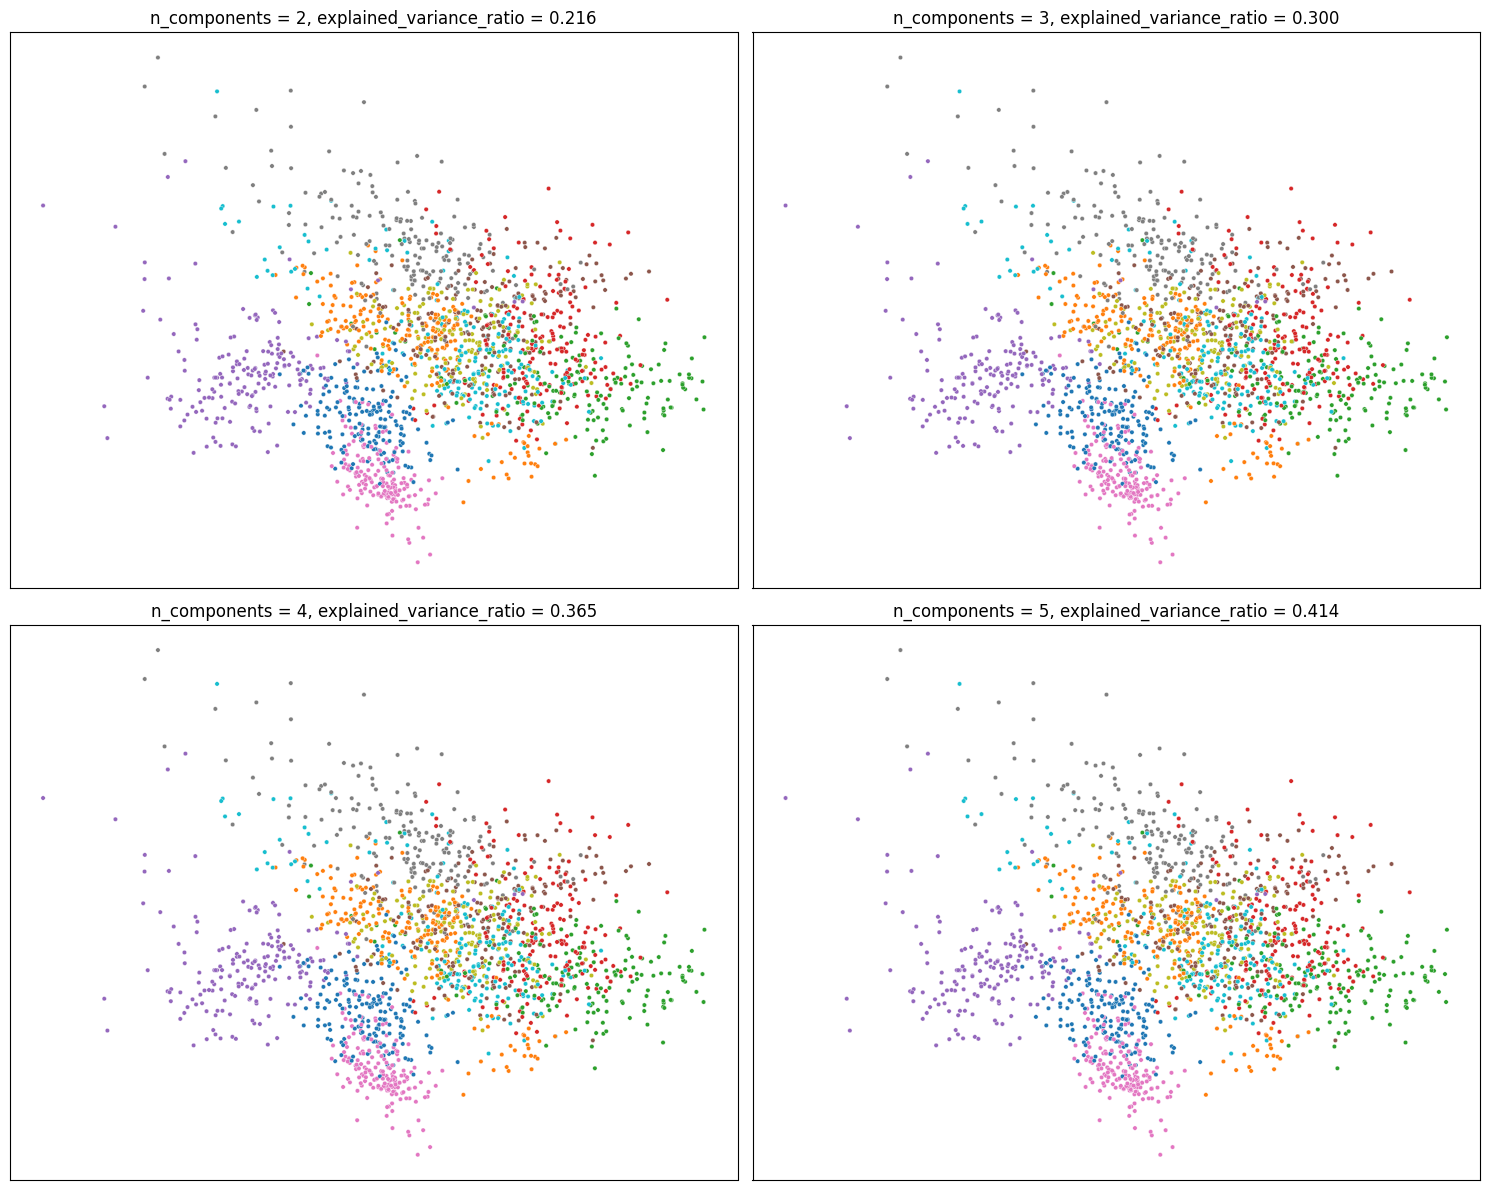

In [84]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

for i, n_comp in enumerate(n_components):
    pca = PCA(n_components=n_comp, random_state=42)
    X_pca = pca.fit_transform(X_digits_scaled)
    ax = axes[i // 2, i % 2]
    sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1],
                    hue=y_digits, palette="tab10", s=10, ax=ax, legend=False)
    ax.set_title(f"n_components = {n_comp}, explained_variance_ratio = {pca.explained_variance_ratio_.sum():.3f}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()